In [ ]:
!pip install -q transformers datasets accelerate emoji==0.6.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [ ]:
import torch
import numpy as np
import pandas as pd

from datasets import load_dataset, Dataset

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

print("GPU available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

GPU available: True
GPU: Tesla T4


In [ ]:
dataset = load_dataset(
    "parquet",
    data_files={
        "train": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/train-00000-of-00001.parquet",
        "validation": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/validation-00000-of-00001.parquet",
        "test": "https://huggingface.co/datasets/QCRI/HumAID-all/resolve/main/data/test-00000-of-00001.parquet"
    }
)

print(dataset)

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 5.05MB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

validation-00000-of-00001.parquet:   0%|          | 0.00/739k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.44MB            

data/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split: 0 examples [00:00, ? examples/s]

Generating validation split: 0 examples [00:00, ? examples/s]

Generating test split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 53531
    })
    validation: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 7793
    })
    test: Dataset({
        features: ['tweet_text', 'class_label'],
        num_rows: 15160
    })
})


In [ ]:
train_df = dataset["train"].to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (53531, 2)
Validation: (7793, 2)
Test: (15160, 2)


In [ ]:
labels = sorted(train_df["class_label"].unique())

label2id = {
    label: i
    for i, label in enumerate(labels)
}

id2label = {
    i: label
    for label, i in label2id.items()
}

print("Number of classes:", len(labels))

for i, label in enumerate(labels):
    print(i, "->", label)

Number of classes: 10
0 -> caution_and_advice
1 -> displaced_people_and_evacuations
2 -> infrastructure_and_utility_damage
3 -> injured_or_dead_people
4 -> missing_or_found_people
5 -> not_humanitarian
6 -> other_relevant_information
7 -> requests_or_urgent_needs
8 -> rescue_volunteering_or_donation_effort
9 -> sympathy_and_support


In [ ]:
train_df["label"] = train_df["class_label"].map(label2id)
val_df["label"] = val_df["class_label"].map(label2id)
test_df["label"] = test_df["class_label"].map(label2id)

print(train_df[["tweet_text", "class_label", "label"]].head())

                                          tweet_text  \
0  Powerful Ecuador quake kills at least 235: POR...   
1  Im at awe and saddened with the #EcuadorEarthq...   
2  RT @RachelAndJun: Our hearts are with everyone...   
3  RT @noticias2000: Ecuador quake death toll has...   
4  RT @pzf: BREAKING PHOTOS: Major damage reporte...   

                              class_label  label  
0                  injured_or_dead_people      3  
1  rescue_volunteering_or_donation_effort      8  
2                    sympathy_and_support      9  
3                  injured_or_dead_people      3  
4       infrastructure_and_utility_damage      2  


In [ ]:
train_dataset = Dataset.from_pandas(
    train_df[["tweet_text", "label"]]
)

val_dataset = Dataset.from_pandas(
    val_df[["tweet_text", "label"]]
)

test_dataset = Dataset.from_pandas(
    test_df[["tweet_text", "label"]]
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

Train: 53531
Validation: 7793
Test: 15160


In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    "vinai/bertweet-base",
    use_fast=False
)

print("BERTweet tokenizer loaded!")

config.json:   0%|          | 0.00/558 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/843k [00:00<?, ?B/s]

bpe.codes:   0%|          | 0.00/1.08M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.91M [00:00<?, ?B/s]

[transformers] emoji is not installed, thus not converting emoticons or emojis into text. Install emoji: pip3 install emoji==0.6.0


BERTweet tokenizer loaded!


In [ ]:
def tokenize_function(examples):
    return tokenizer(
        examples["tweet_text"],
        truncation=True,
        padding="max_length",
        max_length=128
    )

In [ ]:
train_tokenized = train_dataset.map(
    tokenize_function,
    batched=True
)

val_tokenized = val_dataset.map(
    tokenize_function,
    batched=True
)

test_tokenized = test_dataset.map(
    tokenize_function,
    batched=True
)

print("Tokenization complete!")
print(train_tokenized.column_names)

Map:   0%|          | 0/53531 [00:00<?, ? examples/s]

Map:   0%|          | 0/7793 [00:00<?, ? examples/s]

Map:   0%|          | 0/15160 [00:00<?, ? examples/s]

Tokenization complete!
['tweet_text', 'label', 'input_ids', 'attention_mask']


In [ ]:
def compute_metrics(eval_pred):

    predictions, actual_labels = eval_pred

    predicted_labels = predictions.argmax(axis=1)

    accuracy = accuracy_score(
        actual_labels,
        predicted_labels
    )

    f1 = f1_score(
        actual_labels,
        predicted_labels,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "f1": f1
    }

In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/bertweet-base",
    num_labels=len(labels),
    id2label=id2label,
    label2id=label2id
)

print("BERTweet model loaded!")

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  543MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  543MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/bertweet-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.decoder.weight      | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
lm_head.dense.bias          | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
lm_head.decoder.bias        | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.weight  | MISSING    | 
classifier.out_proj.bias    | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


BERTweet model loaded!


In [ ]:
training_args = TrainingArguments(
    output_dir="./resqai_bertweet_best",

    eval_strategy="epoch",
    save_strategy="epoch",

    learning_rate=1e-5,

    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3,

    weight_decay=0.01,

    warmup_steps=500,
    lr_scheduler_type="linear",

    logging_steps=100,

    report_to="none",

    fp16=True,

    load_best_model_at_end=True,

    metric_for_best_model="f1",
    greater_is_better=True,

    save_total_limit=1
)

In [ ]:
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=train_tokenized,
    eval_dataset=val_tokenized,

    compute_metrics=compute_metrics,

    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=1
        )
    ]
)

print("Trainer ready!")

Trainer ready!


In [ ]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.677493,0.693826,0.769023,0.756422
2,0.532168,0.637276,0.784037,0.780514
3,0.486594,0.661504,0.782754,0.777800


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=20076, training_loss=0.6410294599470376, metrics={'train_runtime': 1796.1863, 'train_samples_per_second': 89.408, 'train_steps_per_second': 11.177, 'total_flos': 1.0564207187885568e+16, 'train_loss': 0.6410294599470376, 'epoch': 3.0})

In [ ]:
print("Best validation F1:", trainer.state.best_metric)
print("Best checkpoint:", trainer.state.best_model_checkpoint)

Best validation F1: 0.7805141228981474
Best checkpoint: ./resqai_bertweet_best/checkpoint-13384


In [ ]:
val_output = trainer.predict(
    val_tokenized
)

val_predictions = val_output.predictions.argmax(axis=1)
val_labels = val_output.label_ids

val_accuracy = accuracy_score(
    val_labels,
    val_predictions
)

val_f1 = f1_score(
    val_labels,
    val_predictions,
    average="weighted",
    zero_division=0
)

print("VALIDATION RESULTS")
print("==================")
print("Accuracy:", val_accuracy)
print("Weighted F1:", val_f1)

VALIDATION RESULTS
Accuracy: 0.784036956242782
Weighted F1: 0.7805141228981474


In [ ]:
print(
    classification_report(
        val_labels,
        val_predictions,
        target_names=labels,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                    caution_and_advice       0.71      0.74      0.72       550
      displaced_people_and_evacuations       0.88      0.92      0.90       409
     infrastructure_and_utility_damage       0.75      0.85      0.80       831
                injured_or_dead_people       0.92      0.94      0.93       746
               missing_or_found_people       0.76      0.72      0.74        36
                      not_humanitarian       0.65      0.60      0.63       644
            other_relevant_information       0.61      0.52      0.56      1236
              requests_or_urgent_needs       0.60      0.66      0.63       264
rescue_volunteering_or_donation_effort       0.86      0.89      0.88      2168
                  sympathy_and_support       0.86      0.83      0.85       909

                              accuracy                           0.78      7793
                             macro avg

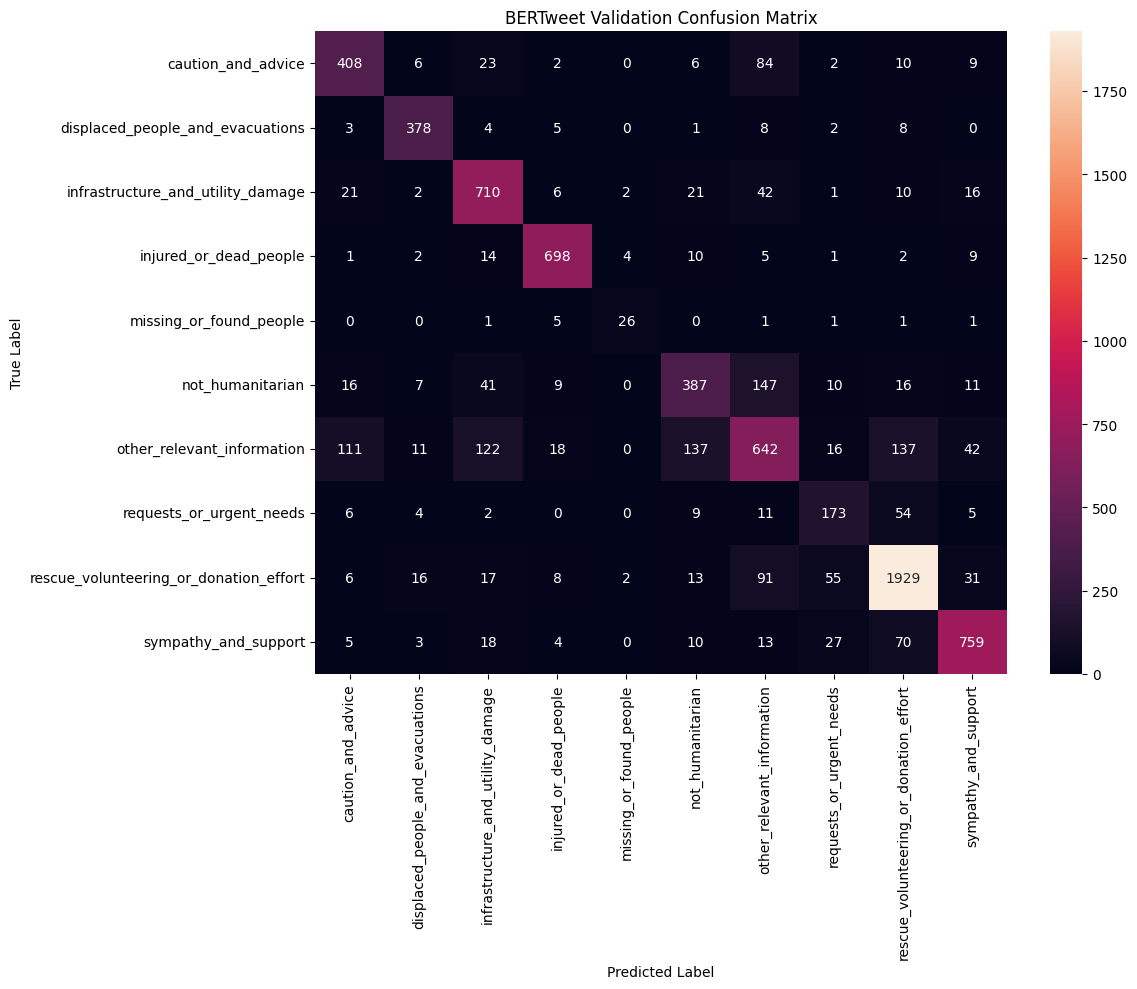

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(
    val_labels,
    val_predictions
)

plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=labels,
    yticklabels=labels
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("BERTweet Validation Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
test_output = trainer.predict(
    test_tokenized
)

test_predictions = test_output.predictions.argmax(axis=1)
test_labels = test_output.label_ids

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_f1 = f1_score(
    test_labels,
    test_predictions,
    average="weighted",
    zero_division=0
)

print("FINAL TEST RESULTS")
print("==================")
print("Accuracy:", test_accuracy)
print("Weighted F1:", test_f1)

FINAL TEST RESULTS
Accuracy: 0.7866754617414248
Weighted F1: 0.7827255826775643


In [ ]:
print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=labels,
        zero_division=0
    )
)

                                        precision    recall  f1-score   support

                    caution_and_advice       0.70      0.72      0.71      1070
      displaced_people_and_evacuations       0.85      0.93      0.89       790
     infrastructure_and_utility_damage       0.78      0.86      0.82      1617
                injured_or_dead_people       0.92      0.95      0.94      1447
               missing_or_found_people       0.78      0.79      0.79        72
                      not_humanitarian       0.66      0.62      0.64      1245
            other_relevant_information       0.61      0.52      0.56      2407
              requests_or_urgent_needs       0.61      0.63      0.62       521
rescue_volunteering_or_donation_effort       0.86      0.90      0.88      4219
                  sympathy_and_support       0.87      0.82      0.85      1772

                              accuracy                           0.79     15160
                             macro avg

In [ ]:
# Save the best BERTweet model
trainer.save_model("./resqai_bertweet_final")

# Save tokenizer
tokenizer.save_pretrained("./resqai_bertweet_final")

print("Final BERTweet model saved successfully!")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Final BERTweet model saved successfully!


In [ ]:
import os

print(os.listdir("./resqai_bertweet_final"))

['training_args.bin', 'config.json', 'vocab.txt', 'bpe.codes', 'model.safetensors', 'added_tokens.json', 'tokenizer_config.json']


In [ ]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in /content:")
print(os.listdir("/content")[:50])

Current directory:
/content

Files in /content:
['.config', 'resqai_bertweet_best', 'resqai_bertweet_final', 'sample_data']


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    for file in files:
        if file in ["model.safetensors", "pytorch_model.bin"]:
            print(os.path.join(root, file))

/content/resqai_bertweet_best/checkpoint-13384/model.safetensors
/content/resqai_bertweet_final/model.safetensors


In [ ]:
from google.colab import drive

drive.mount('/content/drive')




Mounted at /content/drive


In [ ]:
import shutil
import os

source = "/content/resqai_bertweet_best/checkpoint-13384"
destination = "/content/drive/MyDrive/resqai_bertweet_final"

shutil.copytree(
    source,
    destination,
    dirs_exist_ok=True
)

print("MODEL SAVED TO GOOGLE DRIVE!")
print(os.listdir(destination))

MODEL SAVED TO GOOGLE DRIVE!
['training_args.bin', 'trainer_state.json', 'scaler.pt', 'config.json', 'scheduler.pt', 'rng_state.pth', 'model.safetensors', 'optimizer.pt']
